In [1]:
import openml
import optuna

dataset = openml.datasets.get_dataset(36)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)


print(dataset)
print(f"data shape: {X.shape}")
print(f"name features: {y.nunique()}")
X.head()

OpenML Dataset
Name.........: segment
Version......: 1
Format.......: ARFF
Upload Date..: 2014-04-06 23:22:10
Licence......: Public
Download URL.: https://openml.org/data/v1/download/36/segment.arff
OpenML URL...: https://www.openml.org/d/36
# of features: None
data shape: (2310, 19)
name features: 7


,region-centroid-col,region-centroid-row,region-pixel-count,short-line-density-5,short-line-density-2,vedge-mean,vegde-sd,hedge-mean,hedge-sd,intensity-mean,rawred-mean,rawblue-mean,rawgreen-mean,exred-mean,exblue-mean,exgreen-mean,value-mean,saturation-mean,hue-mean
0,218,178,9,0.111111,0.0,0.833333,0.547722,1.111110,0.544331,59.629600,52.4444,75.22220,51.222200,-21.55560,46.7778,-25.22220,75.22220,0.318996,-2.04055
1,113,130,9,0.000000,0.0,0.277778,0.250924,0.333333,0.365148,0.888889,0.0000,2.55556,0.111111,-2.66667,5.0000,-2.33333,2.55556,1.000000,-2.12325
2,202,41,9,0.000000,0.0,0.944448,0.772202,1.111110,1.025600,123.037000,111.8890,139.77800,117.444000,-33.44440,50.2222,-16.77780,139.77800,0.199347,-2.29992
3,32,173,9,0.000000,0.0,1.722220,1.781590,9.000000,6.749490,43.592600,39.5556,52.88890,38.333300,-12.11110,27.8889,-15.77780,52.88890,0.266914,-1.99886
4,61,197,9,0.000000,0.0,1.444440,1.515350,2.611110,1.925460,49.592600,44.2222,61.55560,43.000000,-16.11110,35.8889,-19.77780,61.55560,0.302925,-2.02227


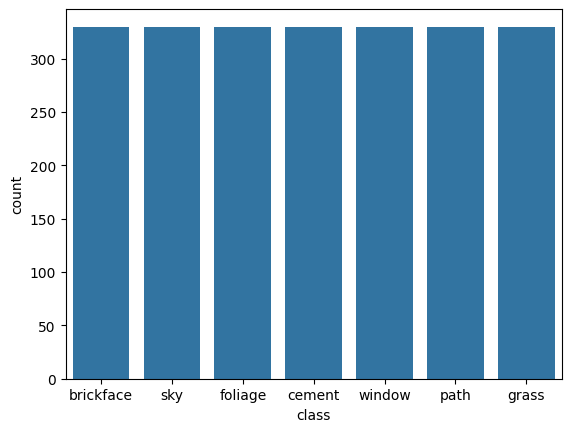

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

class_count = y.value_counts()

sns.barplot(class_count)
plt.show()

## Target Encoding

# Data standardization and train-test split

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Target Encoding
encoder = OneHotEncoder(sparse_output=False)
y_reshaped = y.to_numpy().reshape(-1, 1)
y_encoded = encoder.fit_transform(y_reshaped)

# Data is perfectly balanced, but we keep it as good practice
x_train, x_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train

array([[ 1.66606629,  0.88403034,  0.        , ...,  0.60594303,
        -0.4596314 , -0.43904529],
       [-1.18535198,  1.33853181,  0.        , ...,  0.59037174,
        -0.51694206, -0.4666551 ],
       [-1.66286222, -0.56687821,  0.        , ..., -0.8005931 ,
         1.74126732, -0.66232014],
       ...,
       [-0.85791639,  0.35960556,  0.        , ..., -0.90439737,
         0.63308026,  0.2490941 ],
       [-0.76241434, -1.86045933,  0.        , ...,  2.31091692,
        -1.1650672 , -0.63367963],
       [-0.96706159,  0.16731648,  0.        , ..., -0.83952017,
         0.8757352 , -0.44590587]])

# MLP model

In [4]:
from torch import nn
from typing import Literal

class MLP_classifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, activation:Literal['ReLU', 'Tanh'], input_dim:int=x_train.shape[1], output_dim:int = y_train.shape[1]):
        super(MLP_classifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x


# Optuna for best three models

In [5]:
import os
import numpy as np

import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader, Subset



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss


# Hyperparameters for tunning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10
batch_size = 256
lr = 0.01

# Saving Dir
PATH = os.path.join('Models','folds')
os.makedirs(PATH, exist_ok=True)

# Data Preparation
X_trainval_tensor = torch.from_numpy(x_train).float()
y_trainval_tensor = torch.from_numpy(y_train)
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

N = X_trainval_tensor.shape[0]
idx = np.arange(N)

train_loader = DataLoader(Subset(dataset, idx[:int(0.8*N)]), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(dataset, idx[int(0.8*N):]), batch_size=len(idx[int(0.8*N):]))



def architecture_objective(trial):
    global dataset, DEVICE, num_epochs, batch_size, lr

    n_hidden = trial.suggest_int('n_hidden', 1, 16)
    hidden_dim = trial.suggest_int('hidden_dim', 1, 512)
    activation = trial.suggest_categorical('activation', ['ReLU', 'Tanh'])

    model = MLP_classifier(n_hidden=n_hidden, hidden_dim=hidden_dim, activation=activation)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()


    for epoch in range(num_epochs):
        _train_one_epoch(model, train_loader,optimizer, criterion)

    val_loss = _calculate_val_loss(model, val_loader, criterion)

    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(architecture_objective, n_trials=25, show_progress_bar=True)

trials = study.trials
top_trials = sorted(trials, key=lambda t: t.value, reverse=False)[:3]

print("\n===============================\n")
print("Top 3 parameters\n")
for t in top_trials[:3]:
    print(f'params: {t.params}, val_loss: {t.value}')

/home/franio/Desktop/Uczenie_maszynowe/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
[I 2026-04-07 20:28:03,042] A new study created in memory with name: no-name-59ea6fc7-0b3e-4f9c-9a7c-6fbd4fa25d73


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-07 20:28:04,416] Trial 0 finished with value: 0.14533093110316062 and parameters: {'n_hidden': 3, 'hidden_dim': 144, 'activation': 'Tanh'}. Best is trial 0 with value: 0.14533093110316062.
[I 2026-04-07 20:28:06,566] Trial 1 finished with value: 1.5590238919129242 and parameters: {'n_hidden': 12, 'hidden_dim': 405, 'activation': 'Tanh'}. Best is trial 0 with value: 0.14533093110316062.
[I 2026-04-07 20:28:07,509] Trial 2 finished with value: 1.3334587647302731 and parameters: {'n_hidden': 9, 'hidden_dim': 217, 'activation': 'ReLU'}. Best is trial 0 with value: 0.14533093110316062.
[I 2026-04-07 20:28:08,139] Trial 3 finished with value: 0.13231669889355163 and parameters: {'n_hidden': 6, 'hidden_dim': 216, 'activation': 'ReLU'}. Best is trial 3 with value: 0.13231669889355163.
[I 2026-04-07 20:28:08,880] Trial 4 finished with value: 1.5562159525381551 and parameters: {'n_hidden': 10, 'hidden_dim': 194, 'activation': 'Tanh'}. Best is trial 3 with value: 0.13231669889355163.
[

# Model Training Class

In [ ]:
import copy
from sklearn.model_selection import StratifiedKFold

class ModelTrainer:
    def __init__(
        self,
        x_train: np.ndarray,
        y_train: np.ndarray,
        x_test: np.ndarray,
        y_test: np.ndarray,
        device: torch.device,
        save_dir: str = "Models/folds",
        num_epochs: int = 50,
        batch_size: int = 256,
        lr: float = 0.01,
    ):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.device = device
        self.save_dir = save_dir
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.lr = lr
        os.makedirs(save_dir, exist_ok=True)

    def _build_model(self, model_params: dict) -> nn.Module:
        return MLP_classifier(**model_params).to(self.device)

    def _train_one_epoch(self, model, loader, optimizer, criterion):
        model.train()
        running_loss = 0.0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        return running_loss / len(loader)

    def _calculate_val_loss(self, model, loader, criterion):
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(self.device), y_b.to(self.device)
                running_loss += criterion(model(X_b), y_b).item()
        return running_loss / len(loader)

    def _show_loss(self, history: dict, name: str):
        plt.figure(figsize=(8, 5))
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Loss Curve - {name}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def _train_one_fold(
        self,
        model_params: dict,
        train_loader: DataLoader,
        val_loader: DataLoader,
        fold_idx: int,
        config_name: str,
        plot: bool = True,
    ) -> tuple[str, dict]:
        model = self._build_model(model_params)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_state = None
        history = {"train_loss": [], "val_loss": []}

        for epoch in range(self.num_epochs):
            train_loss = self._train_one_epoch(model, train_loader, optimizer, criterion)
            val_loss = self._calculate_val_loss(model, val_loader, criterion)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())

        ckpt_path = os.path.join(
            self.save_dir, f"{config_name}_fold{fold_idx}.pt"
        )
        torch.save(
            {
                "model_params": model_params,
                "model_state_dict": best_state,
                "best_val_loss": best_val_loss,
                "fold": fold_idx,
                "history": history,
            },
            ckpt_path,
        )
        print(
            f"  Fold {fold_idx} | best val loss: {best_val_loss:.4f} | saved → {ckpt_path}"
        )
        if plot:
            self._show_loss(history, f"{config_name} / fold {fold_idx}")
        return ckpt_path, history

    def train_kfold(
        self,
        model_params: dict,
        config_name: str = "config",
        n_splits: int = 5,
        random_state: int = 42,
        plot: bool = True,
    ) -> tuple[list[str], list[dict]]:
        """Train *n_splits* models via stratified k-fold CV.

        Returns (checkpoint_paths, histories).
        """
        X_tensor = torch.from_numpy(self.x_train).float()
        y_tensor = torch.from_numpy(self.y_train).float()
        dataset = TensorDataset(X_tensor, y_tensor)

        y_labels = np.argmax(self.y_train, axis=1)
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=random_state
        )

        checkpoint_paths: list[str] = []
        histories: list[dict] = []

        print(f"Training config '{config_name}' — {n_splits}-fold CV")
        for fold_idx, (train_ids, val_ids) in enumerate(skf.split(self.x_train, y_labels)):
            train_loader = DataLoader(
                Subset(dataset, train_ids),
                batch_size=self.batch_size,
                shuffle=True,
            )
            val_loader = DataLoader(
                Subset(dataset, val_ids),
                batch_size=len(val_ids),
            )
            ckpt, hist = self._train_one_fold(
                model_params, train_loader, val_loader, fold_idx, config_name, plot
            )
            checkpoint_paths.append(ckpt)
            histories.append(hist)

        return checkpoint_paths, histories

    def evaluate(
        self,
        checkpoint_paths: list[str],
        ensemble_fn: callable = None,
    ) -> dict:
        """Evaluate saved checkpoints on the test set using an ensemble.

        Args:
            checkpoint_paths: list of .pt checkpoint files.
            ensemble_fn: callable (n_models, n_samples, n_classes) -> (n_samples, n_classes).
                         Defaults to mean_response if not provided.

        Returns a dict with per-model metrics, ensemble metrics,
        CrossEntropyLoss, and accuracy.
        """
        if ensemble_fn is None:
            ensemble_fn = mean_response

        X_tensor = torch.from_numpy(self.x_test).float().to(self.device)
        y_tensor = torch.from_numpy(self.y_test).float().to(self.device)
        targets = y_tensor.argmax(dim=1)
        criterion = nn.CrossEntropyLoss()

        all_logits: list[torch.Tensor] = []
        per_model: list[dict] = []

        for path in checkpoint_paths:
            ckpt = torch.load(path, map_location=self.device, weights_only=False)
            model = self._build_model(ckpt["model_params"])
            model.load_state_dict(ckpt["model_state_dict"])
            model.eval()

            with torch.no_grad():
                logits = model(X_tensor)

            loss = criterion(logits, y_tensor).item()
            acc = (logits.argmax(dim=1) == targets).float().mean().item()
            per_model.append({"checkpoint": path, "loss": loss, "accuracy": acc})
            all_logits.append(logits)
            print(f"  {os.path.basename(path)} | loss: {loss:.4f} | acc: {acc:.4f}")

        stacked = torch.stack(all_logits)  # (n_models, n_samples, n_classes)
        combined = ensemble_fn(stacked)

        ensemble_loss = criterion(combined, y_tensor).item()
        ensemble_acc = (combined.argmax(dim=1) == targets).float().mean().item()
        print(f"  Ensemble | loss: {ensemble_loss:.4f} | acc: {ensemble_acc:.4f}")

        return {
            "per_model": per_model,
            "ensemble_loss": ensemble_loss,
            "ensemble_accuracy": ensemble_acc,
        }


def mean_response(all_logits: torch.Tensor) -> torch.Tensor:
    """Average logits across models.

    all_logits: (n_models, n_samples, n_classes)
    returns:    (n_samples, n_classes)
    """
    return all_logits.mean(dim=0)


def majority_voting(all_logits: torch.Tensor) -> torch.Tensor:
    """Hard majority vote across models, returned as vote-count pseudo-logits.

    all_logits: (n_models, n_samples, n_classes)
    returns:    (n_samples, n_classes)  — vote counts per class
    """
    n_models, n_samples, n_classes = all_logits.shape
    preds = all_logits.argmax(dim=2)  # (n_models, n_samples)
    votes = torch.zeros(n_samples, n_classes, device=all_logits.device)
    for model_preds in preds:
        votes.scatter_add_(
            1,
            model_preds.unsqueeze(1),
            torch.ones(n_samples, 1, device=all_logits.device),
        )
    return votes

# Train Models 
Three top params, each for five folds

Training config 'top_16_trial' — 5-fold CV
  Fold 0 | best val loss: 0.0663 | saved → Models/folds/top_16_trial_fold0.pt


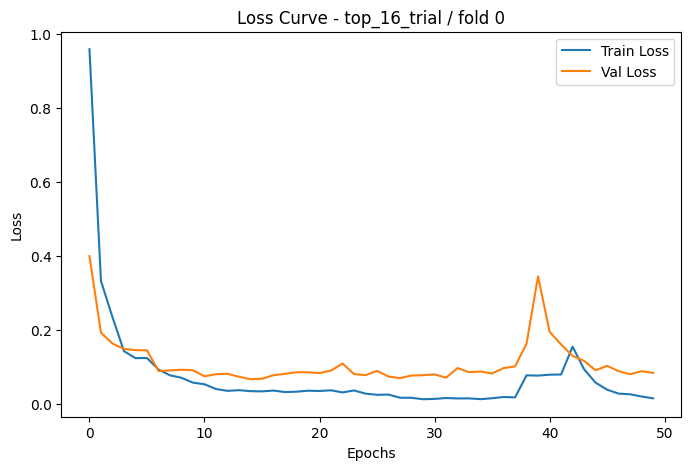

  Fold 1 | best val loss: 0.0952 | saved → Models/folds/top_16_trial_fold1.pt


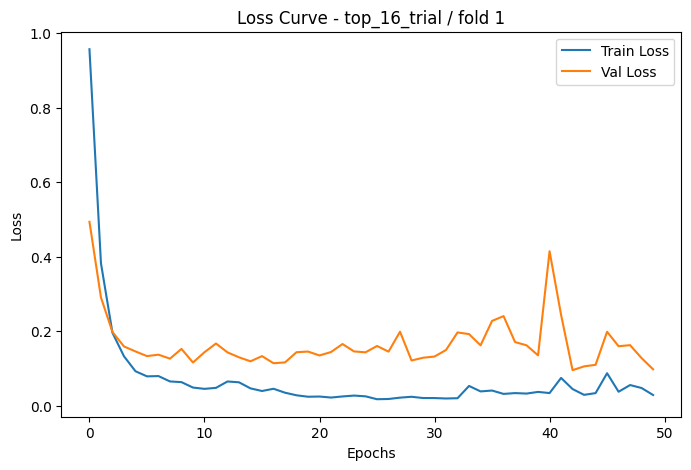

  Fold 2 | best val loss: 0.1037 | saved → Models/folds/top_16_trial_fold2.pt


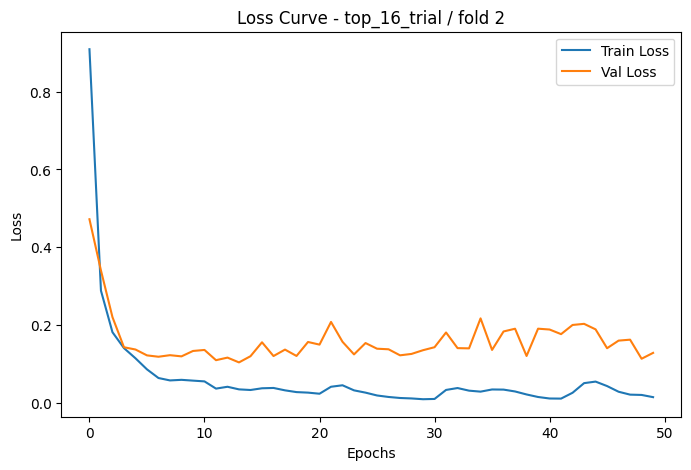

  Fold 3 | best val loss: 0.0830 | saved → Models/folds/top_16_trial_fold3.pt


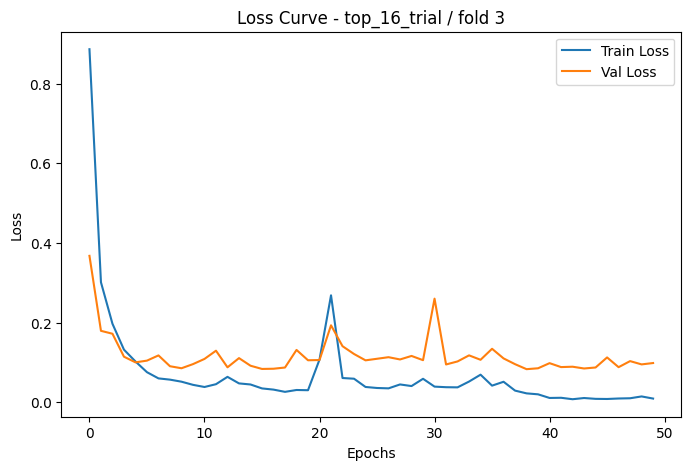

  Fold 4 | best val loss: 0.0901 | saved → Models/folds/top_16_trial_fold4.pt


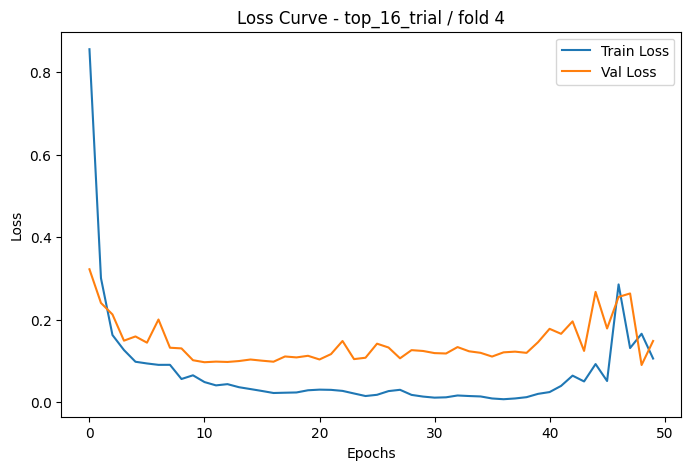

Training config 'top_24_trial' — 5-fold CV
  Fold 0 | best val loss: 0.0592 | saved → Models/folds/top_24_trial_fold0.pt


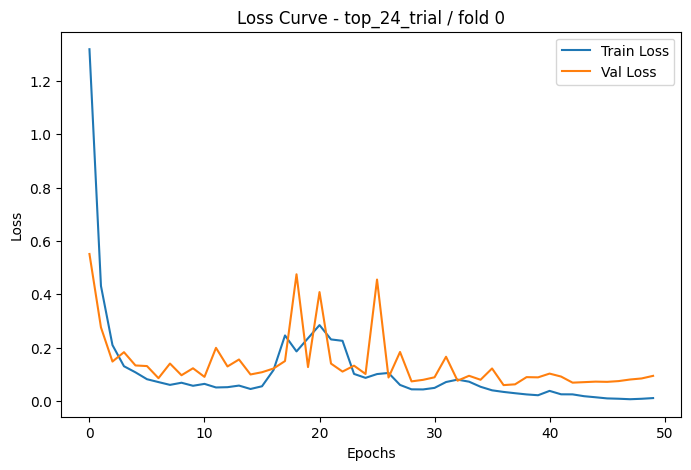

  Fold 1 | best val loss: 0.1228 | saved → Models/folds/top_24_trial_fold1.pt


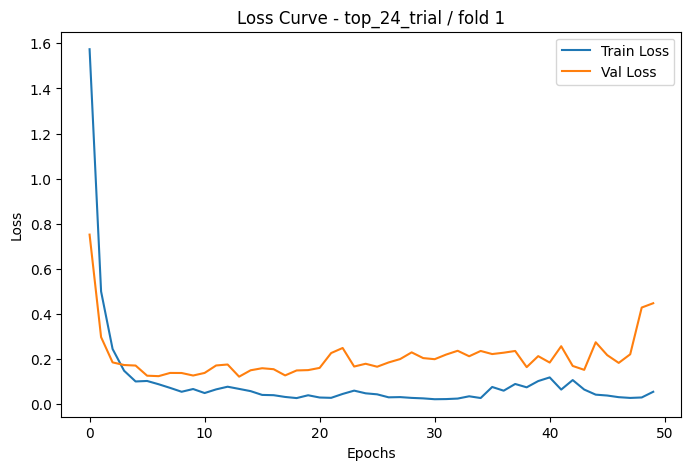

  Fold 2 | best val loss: 0.1048 | saved → Models/folds/top_24_trial_fold2.pt


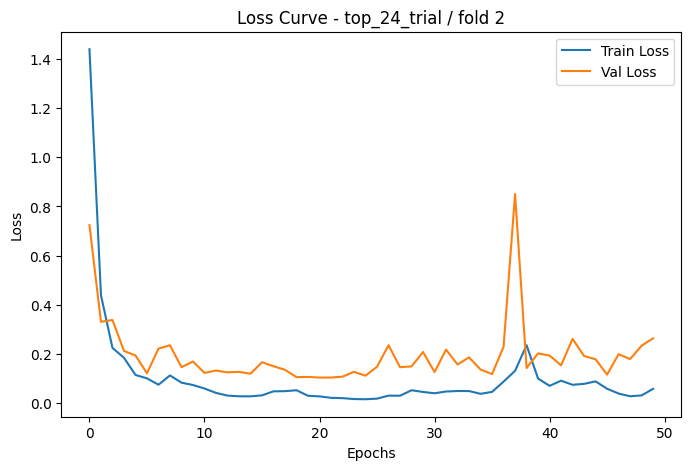

  Fold 3 | best val loss: 0.0439 | saved → Models/folds/top_24_trial_fold3.pt


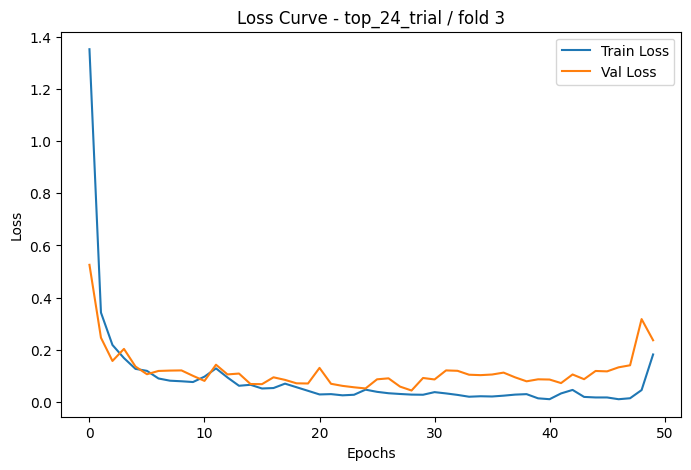

  Fold 4 | best val loss: 0.0715 | saved → Models/folds/top_24_trial_fold4.pt


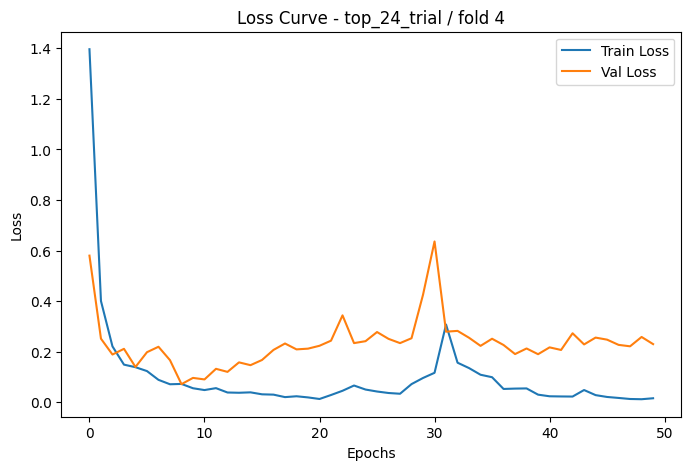

Training config 'top_17_trial' — 5-fold CV
  Fold 0 | best val loss: 0.0722 | saved → Models/folds/top_17_trial_fold0.pt


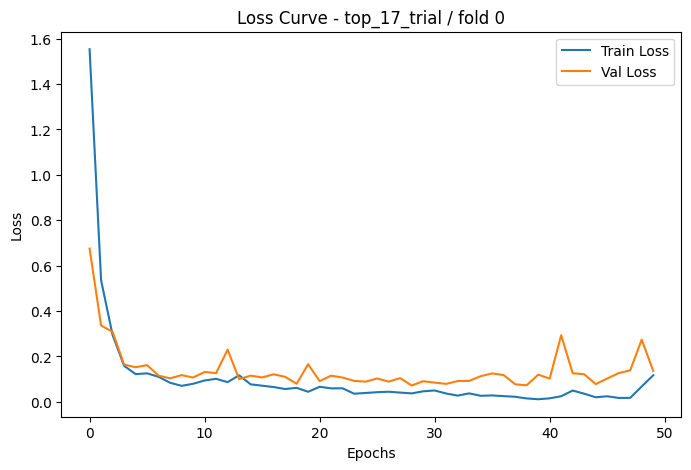

  Fold 1 | best val loss: 0.0945 | saved → Models/folds/top_17_trial_fold1.pt


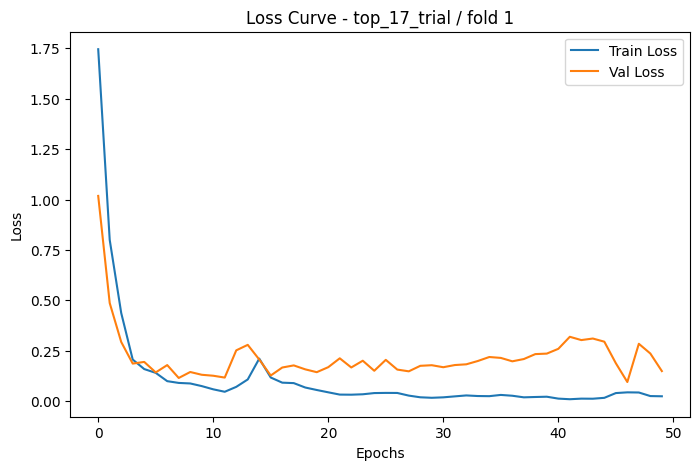

  Fold 2 | best val loss: 0.1124 | saved → Models/folds/top_17_trial_fold2.pt


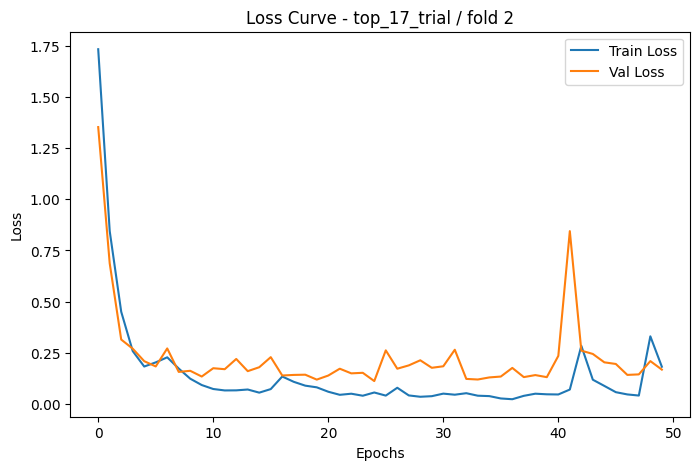

  Fold 3 | best val loss: 0.0609 | saved → Models/folds/top_17_trial_fold3.pt


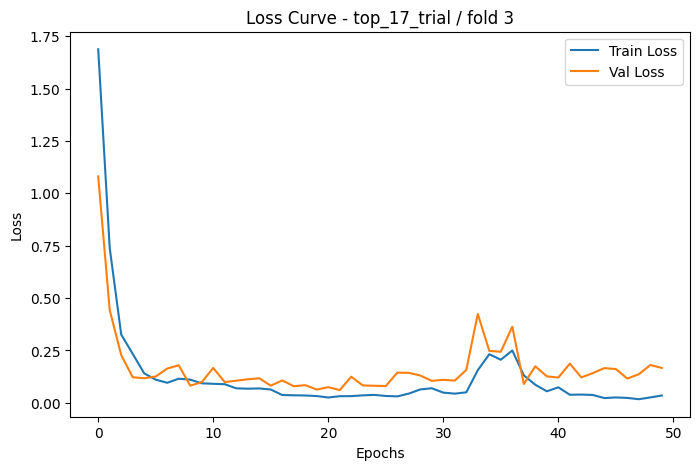

  Fold 4 | best val loss: 0.1528 | saved → Models/folds/top_17_trial_fold4.pt


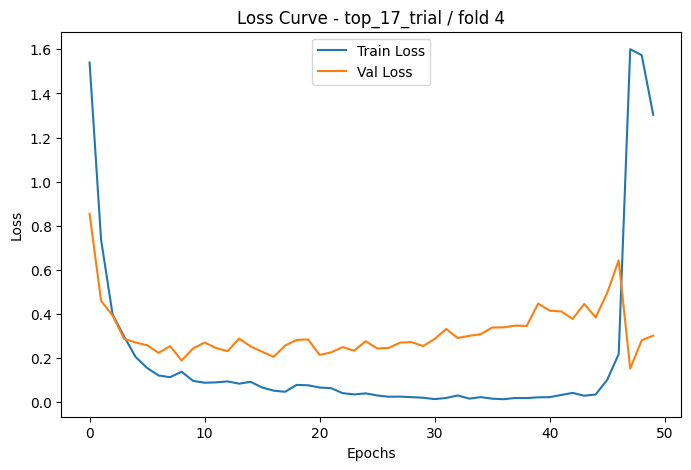

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_trainer = ModelTrainer(x_train, y_train, x_test, y_test, DEVICE, num_epochs=100)

for t in top_trials[:3]:
    model_params = t.params
    model_trainer.train_kfold(model_params, config_name=f"trial_{t.number}", plot=False)
